# Pytorch Computer Vision

We're going to apply the PyTorch Workflow we've been learning in the past couple of sections to computer vision.

Specifically, we're going to cover:

0. Computer vision libraries in PyTorch
1. Load data
2. Prepare data
3. Model 0: Building a baseline model
4. Making predictions and evaluating model 0
5. Setup device agnostic code for future models
6. Model 1: Adding non-linearity
7. Model 2: Convolutional Neural Network (CNN)
8. Comparing our models
9. Evaluating our best model
10. Making a confusion matrix
11. Saving and loading the best performing model

### 0. Computer vision libraries in PyTorch

PyTorch module | What does it do? |
|---------------|------------------|
| `torchvision` | Contains datasets, model architectures and image transformations, often used for computer vision problems. |
| `torchvision.datasets` | Provides many example datasets for tasks like image classification, object detection, video classification and more. Also includes base classes for custom datasets. |
| `torchvision.models` | Contains well-performing and commonly used computer vision model architectures implemented in PyTorch. |
| `torchvision.transforms` | Used to transform images (convert to tensors, normalize, augment) before feeding into a model. |
| `torch.utils.data.Dataset` | Base dataset class for PyTorch. |
| `torch.utils.data.DataLoader` | Creates an iterable over a dataset to load data in batches. |

In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

### 1. Getting a dataset

We're going to start with FashionMNIST.

MNIST stands for Modified National Institute of Standards and Technology.

In [2]:
#setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True,  # download data if it doesn't exist on disk
    transform=ToTensor(),  # images come as PIL format, we want to turn into Torch tensors
    target_transform=None  # you can transform labels as well
)

#setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [3]:
#see training samples
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

### 1.1 **Input and output shapes of a computer vision model**

In [4]:
#shape of image
image.shape # [color_channels=1, height=28, width=28]

torch.Size([1, 28, 28])

 order of current tensor is often referred to as CHW (Color Channels, Height, Width).

 PyTorch generally accepts NCHW (channels first) as the default for many operators. (N- number of images),

 However, PyTorch also explains that NHWC (channels last) performs better and is considered best practice.

 

In [5]:
#how many samples are there
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets) # 60,000 training samples and 10,000 testing samples.

(60000, 60000, 10000, 10000)

In [6]:
#classes
class_names = train_data.classes
class_names
#we're working with 10 different classes, it means our problem is multi-class classification.

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

### 1.2 **Visualizing our data**

image shape: torch.Size([1, 28, 28])


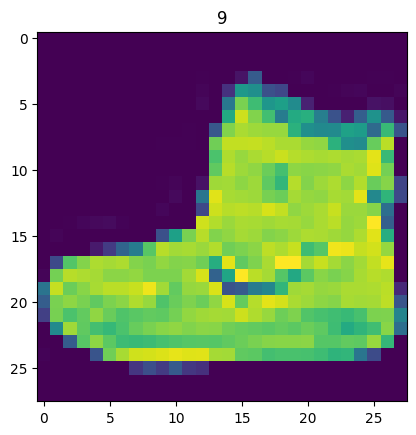

In [7]:
image, label = train_data[0]
print(f"image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label);

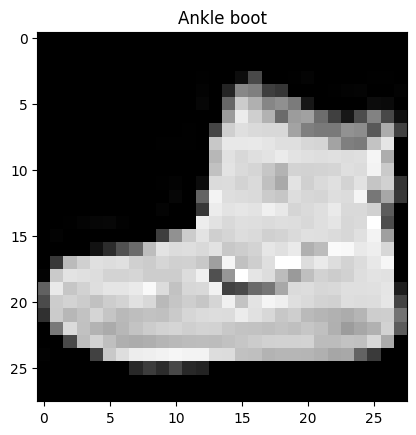

In [8]:
plt.imshow(image.squeeze(), cmap="gray") # turn the image into grayscale using the cmap parameter of plt.imshow().
plt.title(class_names[label]);

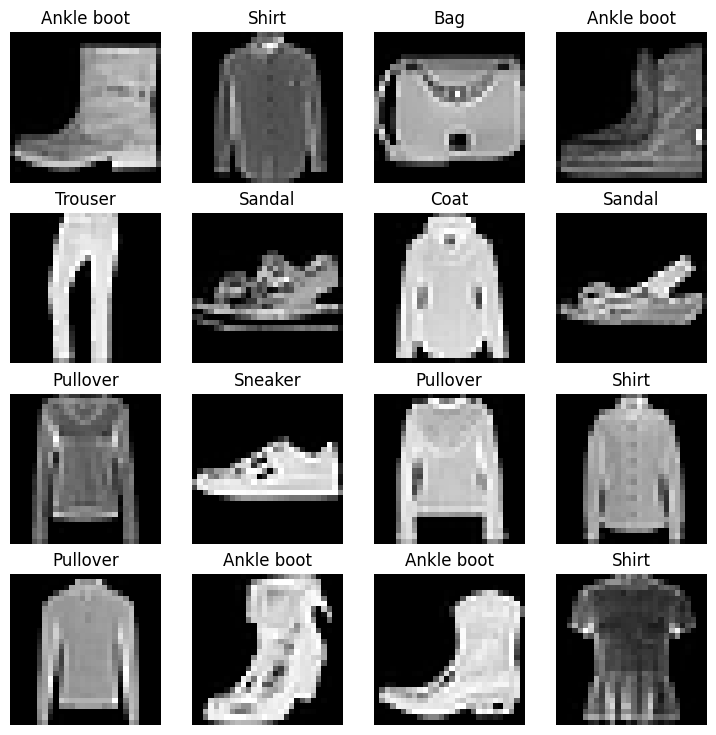

In [9]:
#plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols= 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label  = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);


### **Prepare DataLoader**

The DataLoader does what you think it might do.

It helps load data into a model. For training and for inference.

It turns a large Dataset into a Python iterable of smaller chunks.

These smaller chunks are called **batches** or **mini-batches** and can be set by the batch_size parameter.

In [10]:
from torch.utils.data import DataLoader

#setup the batch size hyperparameter
BATCH_SIZE= 32

#turn datasets into iterables (batches)
train_dataloader= DataLoader(train_data,  # dataset to turn into iterable
                             batch_size=BATCH_SIZE,  # how many samples per batch?
                             shuffle=True # shuffle data every epoch?
                             )
test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader {len(test_dataloader)} batches of {BATCH_SIZE}")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x0000015BB8F44E90>, <torch.utils.data.dataloader.DataLoader object at 0x0000015BB7E5D690>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader 313 batches of 32


In [11]:
# Check  what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
label: 6, label size: torch.Size([])


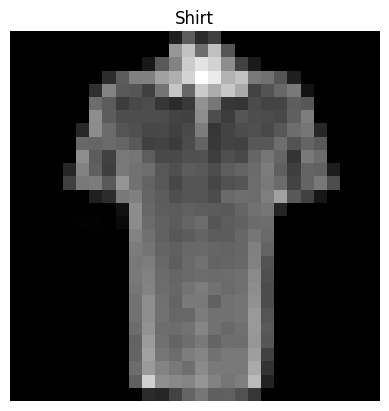

In [12]:
#show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("off")
print(f"Image size: {img.shape}")
print(f"label: {label}, label size: {label.shape}")

### **Model 0: Build a baseline model**

* build a baseline model by subclassing nn.Module.
* Our baseline will consist of two nn.Linear() layers.
* nn.Flatten() compresses the dimensions of a tensor into a single vector.


In [22]:
#create a flatten layer
flatten_model = nn.Flatten()   # all nn modules function as a model

#get a single sample
x = train_features_batch[0]

#flatten the sample
output = flatten_model(x)  # perform forward pass

#print out what happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"shape after flattening: {output.shape} -> [color_channels, height*width]")

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


nn.Flatten() layer took our shape from [color_channels, height, width] to [color_channels, height*width].

Why do this?

Because we've now turned our pixel data from height and width dimensions into one long feature vector.



----------------------------------
create our first model using nn.Flatten() as the first layer.

In [25]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # neural networks like their inputs in vector form
            nn.Linear(in_features=input_shape, out_features=hidden_units), # in_features = number of features in a data sample (784 pixels)
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    
    def forward(self, x):
        return self.layer_stack(x)

 Now need to set the following parameters:

In [ ]:
torch.manual_seed(42)

#need to setup model with input parameters
model_0 = FashionMNISTModelV0(input_shape=784, # one for every pixel (28x28)
                             hidden_units=10,  # how many units in the hidden layer
                            output_shape=len(class_names)) # one for every class

model_0.to("cpu")

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

 ### **Setup loss, optimizer and evaluation metrics**